# Validação do TCN Etapa 5b — multi-seed e expanding-window CV

## Contexto

O melhor resultado prático até agora é o **TCN [32,32] + features de sentimento engenheiradas (Etapa 5b)**,
que atingiu AUC = 0.643 em uma única janela com uma única seed.

O Capítulo 5 mostrou que o Transformer (AUC = 0.709 na avaliação original) **colapsa** sob:
- validação multi-seed (alta variância, seeds ruins caem abaixo de 0.10)
- expanding-window CV (AUC médio cai para níveis próximos do baseline)

**Pergunta central deste notebook:** o TCN [32,32] sofre o mesmo colapso?

## Protocolo

Idêntico ao adotado para o Transformer no Capítulo 5:

1. **Multi-seed** (20 seeds, janela única 70/15/15): distribuição de AUC do TCN com features Etapa 5b.
2. **Expanding-window CV** (5 folds × 5 seeds): min_train=600, val=90, test=90, step=90.
3. Referência: XGB baseline expanding-window AUC = 0.700 (ITUB4, `results_expanding_cv.csv`).

## Features Etapa 5b (26 dimensões)

| Grupo | Features |
|---|---|
| Preço (11) | Close, Volume, return, ma7, ma21, std21, lag_1..lag_5 |
| Sentimento base (5) | n_articles, mean_logit_pos/neg/neu, mean_sentiment |
| MAs de sentimento (6) | mean_logit_{pos,neg,neu}_ma7, mean_logit_{pos,neg,neu}_ma21 |
| Deltas (2) | mean_logit_pos_delta, mean_logit_neg_delta |
| Razão/volatilidade/volume (3) | logit_ratio_pos_neg, sentiment_volatility, article_volume_ma7 |

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Adiciona o diretório pai ao path para importar eval_utils
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../7.model-evaluation/shared'))

from eval_utils import walk_forward_split, make_binary_target, bootstrap_auc_ci
from models import TCNClassifier, TimeSeriesDataset

# ── Caminhos ──────────────────────────────────────────────────────────────────
PRICE_PATH    = '../2.stocks/dataset_full.csv'
SENTIMENT_PATH = '../4.finbert-br/itub4_daily_sentiment.csv'

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
HORIZON    = 5
WINDOW     = 30
N_SEEDS    = 20
BATCH_SIZE = 64
MAX_EPOCHS = 200
PATIENCE   = 10
LR         = 1e-3
WD         = 1e-4

# Expanding-window CV
MIN_TRAIN  = 600
VAL_DAYS   = 90
TEST_DAYS  = 90
STEP_DAYS  = 90
N_SEEDS_CV = 5

# Baseline de referência (XGB expanding-window, ITUB4, Capítulo 5)
XGB_BASELINE_AUC = 0.700

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
print(f'PyTorch: {torch.__version__}')

device: cuda
PyTorch: 2.6.0+cu124


## 1. Carregamento e preparação dos dados

### 1.1 Colunas de features

In [2]:
PRICE_COLS = [
    'Close', 'Volume', 'return', 'ma7', 'ma21', 'std21',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'
]

SENT_BASE_COLS = [
    'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment'
]

# Features engenheiradas da Etapa 5b — serão criadas abaixo
SENT_ENG_COLS = [
    'mean_logit_pos_ma7',  'mean_logit_neg_ma7',  'mean_logit_neu_ma7',
    'mean_logit_pos_ma21', 'mean_logit_neg_ma21', 'mean_logit_neu_ma21',
    'mean_logit_pos_delta', 'mean_logit_neg_delta',
    'logit_ratio_pos_neg', 'sentiment_volatility', 'article_volume_ma7'
]

STAGE5B_FEATURES = PRICE_COLS + SENT_BASE_COLS + SENT_ENG_COLS
print(f'Total de features Etapa 5b: {len(STAGE5B_FEATURES)}')
print(f'  Preço: {len(PRICE_COLS)} | Sentimento base: {len(SENT_BASE_COLS)} | Engenheirado: {len(SENT_ENG_COLS)}')

Total de features Etapa 5b: 27
  Preço: 11 | Sentimento base: 5 | Engenheirado: 11


### 1.2 Leitura e merge de preços + sentimento

In [3]:
# ── Preços ────────────────────────────────────────────────────────────────────
px = pd.read_csv(PRICE_PATH, parse_dates=['Date']).rename(columns={'Date': 'date'})
px = px[['date'] + PRICE_COLS].sort_values('date').reset_index(drop=True)

# ── Sentimento ────────────────────────────────────────────────────────────────
sent = pd.read_csv(SENTIMENT_PATH, parse_dates=['date'])
sent = sent[['date'] + SENT_BASE_COLS].sort_values('date').reset_index(drop=True)

# ── Merge e forward-fill ──────────────────────────────────────────────────────
df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
df[SENT_BASE_COLS] = df[SENT_BASE_COLS].ffill().fillna(0)

print(f'Linhas após merge: {len(df)}')
print(f'Período: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'NaN restantes em sentimento: {df[SENT_BASE_COLS].isna().sum().sum()}')

Linhas após merge: 1227
Período: 2021-04-28 → 2026-03-26
NaN restantes em sentimento: 0


### 1.3 Engenharia de features de sentimento (Etapa 5b)

In [4]:
# Médias móveis de logits
for col in ['mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu']:
    df[f'{col}_ma7']  = df[col].rolling(7,  min_periods=1).mean()
    df[f'{col}_ma21'] = df[col].rolling(21, min_periods=1).mean()

# Deltas (mudança de 1 dia)
df['mean_logit_pos_delta'] = df['mean_logit_pos'].diff().fillna(0)
df['mean_logit_neg_delta'] = df['mean_logit_neg'].diff().fillna(0)

# Razão positivo/negativo (evitar divisão por zero)
df['logit_ratio_pos_neg'] = (
    df['mean_logit_pos'] / (df['mean_logit_neg'].abs() + 1e-8)
)

# Volatilidade do sentimento (std 7 dias)
df['sentiment_volatility'] = df['mean_sentiment'].rolling(7, min_periods=1).std().fillna(0)

# Volume de artigos MA7
df['article_volume_ma7'] = df['n_articles'].rolling(7, min_periods=1).mean()

# ── Target binário h=5 ────────────────────────────────────────────────────────
df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
df = df.dropna(subset=['target']).reset_index(drop=True)

# Verificar que todas as features estão presentes
missing = [c for c in STAGE5B_FEATURES if c not in df.columns]
assert len(missing) == 0, f'Features ausentes: {missing}'

print(f'Dataset final: {len(df)} amostras')
print(f'Balanceamento (sobe): {df["target"].mean():.3f}')
print(f'Features NaN após engenharia: {df[STAGE5B_FEATURES].isna().sum().sum()}')
df[STAGE5B_FEATURES].describe().round(3)

Dataset final: 1222 amostras
Balanceamento (sobe): 0.540
Features NaN após engenharia: 0


,Close,Volume,return,ma7,ma21,std21,lag_1,lag_2,lag_3,lag_4,...,mean_logit_neg_ma7,mean_logit_neu_ma7,mean_logit_pos_ma21,mean_logit_neg_ma21,mean_logit_neu_ma21,mean_logit_pos_delta,mean_logit_neg_delta,logit_ratio_pos_neg,sentiment_volatility,article_volume_ma7
count,1222.000,1.222000e+03,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,...,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000,1222.000
mean,23.499,3.309745e+07,0.001,23.439,23.289,0.631,23.479,23.459,23.439,23.418,...,-0.400,-0.950,-0.825,-0.401,-0.952,-0.001,-0.000,-2.782,0.483,2.366
std,7.465,1.631886e+07,0.016,7.402,7.226,0.394,7.448,7.431,7.413,7.394,...,0.638,0.382,0.358,0.449,0.271,1.162,1.455,7.383,0.187,0.984
min,13.795,6.695412e+06,-0.180,14.017,14.292,0.193,13.795,13.795,13.795,13.795,...,-2.201,-1.729,-1.845,-1.549,-1.466,-3.455,-4.024,-158.725,0.000,1.000
25%,17.774,2.211327e+07,-0.008,17.750,17.625,0.399,17.763,17.750,17.747,17.745,...,-0.857,-1.231,-1.041,-0.689,-1.145,-0.559,-0.841,-2.161,0.366,1.714
50%,20.399,2.970794e+07,0.001,20.150,20.091,0.535,20.390,20.381,20.367,20.351,...,-0.394,-1.000,-0.842,-0.371,-1.017,0.000,0.000,-1.084,0.473,2.143
75%,26.841,4.079398e+07,0.010,26.833,26.799,0.729,26.810,26.800,26.786,26.774,...,0.051,-0.727,-0.617,-0.070,-0.769,0.545,0.773,-0.240,0.604,2.857
max,48.946,1.820390e+08,0.083,48.094,46.860,3.109,48.946,48.946,48.946,48.946,...,1.473,0.576,0.628,0.639,-0.186,3.404,4.032,1.041,1.018,7.143


### 1.4 Split único (multi-seed) — 70/15/15 walk-forward

In [5]:
train_df, val_df, test_df = walk_forward_split(df)

print(f'Train : {len(train_df):4d} dias | sobe = {train_df["target"].mean():.3f}')
print(f'Val   : {len(val_df):4d} dias | sobe = {val_df["target"].mean():.3f}')
print(f'Test  : {len(test_df):4d} dias | sobe = {test_df["target"].mean():.3f}')
print(f'Shift train→test: Δ = {test_df["target"].mean() - train_df["target"].mean():+.3f}')

Train :  855 dias | sobe = 0.529
Val   :  183 dias | sobe = 0.536
Test  :  184 dias | sobe = 0.598
Shift train→test: Δ = +0.069


## 2. Funções auxiliares

In [6]:
def make_windows(X: np.ndarray, y: np.ndarray, window: int = WINDOW):
    """Cria janelas deslizantes (n_samples, window, n_features) e targets alinhados."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def train_tcn_one_run(
    train_df_: pd.DataFrame,
    val_df_: pd.DataFrame,
    test_df_: pd.DataFrame,
    seed: int,
    num_channels: list = None,
    verbose: bool = False,
) -> dict | None:
    """
    Treina TCN [32,32] + Etapa 5b features para uma seed/fold.
    Retorna dict com AUC e metadados, ou None se test set inválido.

    Usa BCELoss (o TCNClassifier já aplica Sigmoid internamente).
    """
    if num_channels is None:
        num_channels = [32, 32]

    torch.manual_seed(seed)
    np.random.seed(seed)

    # Escalonamento
    sc = StandardScaler().fit(train_df_[STAGE5B_FEATURES])
    Xtr = sc.transform(train_df_[STAGE5B_FEATURES])
    ytr = train_df_['target'].values.astype(np.float32)
    Xva = sc.transform(val_df_[STAGE5B_FEATURES])
    yva = val_df_['target'].values.astype(np.float32)
    Xte = sc.transform(test_df_[STAGE5B_FEATURES])
    yte = test_df_['target'].values.astype(np.float32)

    # Janelas deslizantes
    Xtw, ytw = make_windows(Xtr, ytr)
    Xvw, yvw = make_windows(Xva, yva)
    Xew, yew = make_windows(Xte, yte)

    # Validação mínima do test set
    if len(yew) < 5 or len(np.unique(yew)) < 2:
        return None

    # DataLoaders
    train_ds = TimeSeriesDataset(Xtw, ytw)
    val_ds   = TimeSeriesDataset(Xvw, yvw)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # Modelo
    n_features = len(STAGE5B_FEATURES)
    model = TCNClassifier(
        input_size=n_features,
        num_channels=num_channels,
        kernel_size=3,
        dropout=0.2,
    ).to(device)

    # TCNClassifier usa Sigmoid → BCELoss (não BCEWithLogitsLoss)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

    best_val_loss = float('inf')
    best_state    = None
    bad_epochs    = 0

    for epoch in range(MAX_EPOCHS):
        # ── Treino ──────────────────────────────────────────────────────────────
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)          # já são probabilidades (sigmoid)
            loss  = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # ── Validação ───────────────────────────────────────────────────────────
        model.eval()
        val_loss_accum = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb)
                val_loss_accum += criterion(preds, yb).item() * len(yb)
        val_loss = val_loss_accum / max(len(yvw), 1)

        # ── Early stopping ──────────────────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                if verbose:
                    print(f'    early stop em epoch {epoch + 1}')
                break

    # ── Inferência no test set ──────────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    Xe_t = torch.tensor(Xew, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_score = model(Xe_t).cpu().numpy()

    auc = float(roc_auc_score(yew, y_score))
    return {
        'auc':           auc,
        'train_balance': float(train_df_['target'].mean()),
        'val_balance':   float(val_df_['target'].mean()),
        'test_balance':  float(test_df_['target'].mean()),
        'n_test':        int(len(yew)),
    }


def expanding_folds(n_total, min_train=MIN_TRAIN, val=VAL_DAYS, test=TEST_DAYS, step=STEP_DAYS):
    """Gera lista de (train_end, val_end, test_end) para expanding-window CV."""
    folds = []
    train_end = min_train
    while train_end + val + test <= n_total:
        folds.append((train_end, train_end + val, train_end + val + test))
        train_end += step
    return folds


print('Funções auxiliares definidas.')
print(f'Dimensão de entrada do TCN: {len(STAGE5B_FEATURES)} features')

Funções auxiliares definidas.
Dimensão de entrada do TCN: 27 features


## 3. Experimento 1 — Multi-seed (20 seeds, janela única)

**Protocolo:** split fixo walk-forward 70/15/15; apenas o seed de treinamento varia.
O resultado esperado se o TCN for robusto: distribuição estreita centrada em torno de 0.64.
O resultado esperado se o TCN for frágil (como o Transformer): distribuição ampla com seeds ruins abaixo de 0.50.

In [7]:
rows_ms = []
t0 = time.time()

for seed in range(N_SEEDS):
    result = train_tcn_one_run(train_df, val_df, test_df, seed=seed)
    if result is not None:
        result['seed'] = seed
        rows_ms.append(result)
    elapsed = time.time() - t0
    auc_str = f"{result['auc']:.3f}" if result else 'N/A'
    print(f'seed {seed:2d} | AUC = {auc_str} | {elapsed:.0f}s')

results_ms = pd.DataFrame(rows_ms)
print(f'\nConcluído: {len(results_ms)} seeds válidas em {time.time() - t0:.0f}s')

seed  0 | AUC = 0.442 | 3s
seed  1 | AUC = 0.623 | 4s
seed  2 | AUC = 0.654 | 5s
seed  3 | AUC = 0.455 | 6s
seed  4 | AUC = 0.465 | 7s
seed  5 | AUC = 0.439 | 8s
seed  6 | AUC = 0.404 | 9s
seed  7 | AUC = 0.505 | 10s
seed  8 | AUC = 0.670 | 11s
seed  9 | AUC = 0.550 | 11s
seed 10 | AUC = 0.444 | 12s
seed 11 | AUC = 0.466 | 13s
seed 12 | AUC = 0.439 | 14s
seed 13 | AUC = 0.459 | 15s
seed 14 | AUC = 0.384 | 16s
seed 15 | AUC = 0.453 | 17s
seed 16 | AUC = 0.432 | 17s
seed 17 | AUC = 0.685 | 18s
seed 18 | AUC = 0.609 | 19s
seed 19 | AUC = 0.691 | 20s

Concluído: 20 seeds válidas em 20s


### 3.1 Estatísticas descritivas — multi-seed

In [8]:
aucs_ms = results_ms['auc'].values

print('=== Estatísticas Multi-seed — TCN [32,32] + Etapa 5b ===')
print(f'  N seeds válidas : {len(aucs_ms)}')
print(f'  Média           : {aucs_ms.mean():.3f}')
print(f'  Desvio padrão   : {aucs_ms.std():.3f}')
print(f'  Mediana         : {np.median(aucs_ms):.3f}')
print(f'  Mínimo          : {aucs_ms.min():.3f}  (seed {aucs_ms.argmin()})')
print(f'  Máximo          : {aucs_ms.max():.3f}  (seed {aucs_ms.argmax()})')
print(f'  IQR             : [{np.percentile(aucs_ms,25):.3f}, {np.percentile(aucs_ms,75):.3f}]')
print(f'  Seeds ≥ 0.643   : {(aucs_ms >= 0.643).sum()}/{len(aucs_ms)} ({(aucs_ms >= 0.643).mean()*100:.0f}%)')
print(f'  Seeds ≥ 0.60    : {(aucs_ms >= 0.60).sum()}/{len(aucs_ms)}')
print(f'  Seeds < 0.50    : {(aucs_ms < 0.50).sum()}/{len(aucs_ms)}')
print()
print(f'  Referência XGB expanding-window: {XGB_BASELINE_AUC:.3f}')
print(f'  Resultado original TCN (seed=42): 0.643')

results_ms.round(3)

=== Estatísticas Multi-seed — TCN [32,32] + Etapa 5b ===
  N seeds válidas : 20
  Média           : 0.513
  Desvio padrão   : 0.100
  Mediana         : 0.462
  Mínimo          : 0.384  (seed 14)
  Máximo          : 0.691  (seed 19)
  IQR             : [0.442, 0.612]
  Seeds ≥ 0.643   : 4/20 (20%)
  Seeds ≥ 0.60    : 6/20
  Seeds < 0.50    : 12/20

  Referência XGB expanding-window: 0.700
  Resultado original TCN (seed=42): 0.643


,auc,train_balance,val_balance,test_balance,n_test,seed
0,0.442,0.529,0.536,0.598,154,0
1,0.623,0.529,0.536,0.598,154,1
2,0.654,0.529,0.536,0.598,154,2
3,0.455,0.529,0.536,0.598,154,3
4,0.465,0.529,0.536,0.598,154,4
5,0.439,0.529,0.536,0.598,154,5
6,0.404,0.529,0.536,0.598,154,6
7,0.505,0.529,0.536,0.598,154,7
8,0.670,0.529,0.536,0.598,154,8
9,0.550,0.529,0.536,0.598,154,9


## 4. Experimento 2 — Expanding-window CV (5 folds × 5 seeds)

**Protocolo:** expanding-window com min_train=600, val=90, test=90, step=90.
Para cada fold, o modelo é treinado 5 vezes com seeds diferentes; o AUC do fold é a média.

Este protocolo elimina o viés de distribuição estática e avalia o modelo em múltiplos regimes de mercado.

In [9]:
folds = expanding_folds(len(df))
print(f'Total de folds: {len(folds)}')
for fi, (te, ve, tse) in enumerate(folds):
    print(f'  Fold {fi}: train=[0, {te}) | val=[{te}, {ve}) | test=[{ve}, {tse})')
    train_sub = df.iloc[:te]
    val_sub   = df.iloc[te:ve]
    test_sub  = df.iloc[ve:tse]
    bal = test_sub["target"].mean()
    print(
        f'          n_train={len(train_sub)} | n_val={len(val_sub)}'
        f' | n_test={len(test_sub)} | balance_test={bal:.3f}'
    )

Total de folds: 5
  Fold 0: train=[0, 600) | val=[600, 690) | test=[690, 780)
          n_train=600 | n_val=90 | n_test=90 | balance_test=0.500
  Fold 1: train=[0, 690) | val=[690, 780) | test=[780, 870)
          n_train=690 | n_val=90 | n_test=90 | balance_test=0.600
  Fold 2: train=[0, 780) | val=[780, 870) | test=[870, 960)
          n_train=780 | n_val=90 | n_test=90 | balance_test=0.500
  Fold 3: train=[0, 870) | val=[870, 960) | test=[960, 1050)
          n_train=870 | n_val=90 | n_test=90 | balance_test=0.589
  Fold 4: train=[0, 960) | val=[960, 1050) | test=[1050, 1140)
          n_train=960 | n_val=90 | n_test=90 | balance_test=0.644


In [10]:
rows_cv = []
t0 = time.time()

for fi, (train_end, val_end, test_end) in enumerate(folds):
    train_sub = df.iloc[:train_end]
    val_sub   = df.iloc[train_end:val_end]
    test_sub  = df.iloc[val_end:test_end]

    fold_aucs = []
    for seed in range(N_SEEDS_CV):
        result = train_tcn_one_run(train_sub, val_sub, test_sub, seed=seed)
        if result is not None:
            result['fold'] = fi
            result['seed'] = seed
            rows_cv.append(result)
            fold_aucs.append(result['auc'])

    elapsed  = time.time() - t0
    mean_auc = np.mean(fold_aucs) if fold_aucs else float("nan")
    shift    = test_sub['target'].mean() - train_sub['target'].mean()
    n_valid  = len(fold_aucs)
    print(
        f'fold {fi} | AUC medio = {mean_auc:.3f}'
        f' | shift = {shift:+.3f}'
        f' | seeds validas = {n_valid}/{N_SEEDS_CV}'
        f' | {elapsed:.0f}s'
    )

results_cv = pd.DataFrame(rows_cv)
results_cv['shift'] = results_cv['test_balance'] - results_cv['train_balance']

print("Concluido: " + str(len(results_cv)) + " runs em " + f"{time.time() - t0:.0f}s")

fold 0 | AUC medio = 0.540 | shift = +0.002 | seeds validas = 5/5 | 3s
fold 1 | AUC medio = 0.565 | shift = +0.080 | seeds validas = 5/5 | 7s
fold 2 | AUC medio = 0.427 | shift = -0.018 | seeds validas = 5/5 | 12s
fold 3 | AUC medio = 0.555 | shift = +0.062 | seeds validas = 5/5 | 16s
fold 4 | AUC medio = 0.692 | shift = +0.120 | seeds validas = 5/5 | 21s
Concluido: 25 runs em 21s


### 4.1 Agregação por fold

In [11]:
fold_agg = (
    results_cv
    .groupby('fold')
    .agg(
        auc_mean  = ('auc', 'mean'),
        auc_std   = ('auc', 'std'),
        auc_min   = ('auc', 'min'),
        auc_max   = ('auc', 'max'),
        n_seeds   = ('auc', 'count'),
        shift     = ('shift', 'first'),
        train_bal = ('train_balance', 'first'),
        test_bal  = ('test_balance', 'first'),
        n_test    = ('n_test', 'first'),
    )
    .reset_index()
)

print(fold_agg.round(3).to_string(index=False))

aucs_cv = results_cv['auc'].values

print('\n=== Estatísticas Expanding-Window CV — TCN [32,32] + Etapa 5b ===')
print(f'  Total de runs (folds × seeds) : {len(aucs_cv)}')
print(f'  Média AUC (todas as runs)     : {aucs_cv.mean():.3f}')
print(f'  Desvio padrão                 : {aucs_cv.std():.3f}')
print(f'  Mediana                       : {np.median(aucs_cv):.3f}')
print(f'  Mínimo                        : {aucs_cv.min():.3f}')
print(f'  Máximo                        : {aucs_cv.max():.3f}')
print(f'  Média sobre folds (fold_agg)  : {fold_agg["auc_mean"].mean():.3f} ± {fold_agg["auc_mean"].std():.3f}')
print()
print(f'  Referência XGB expanding-window (ITUB4): {XGB_BASELINE_AUC:.3f}')
delta = fold_agg['auc_mean'].mean() - XGB_BASELINE_AUC
print(f'  TCN vs XGB baseline (Δ):               {delta:+.3f}')

 fold  auc_mean  auc_std  auc_min  auc_max  n_seeds  shift  train_bal  test_bal  n_test
    0     0.540    0.073    0.437    0.635        5  0.002      0.498     0.500      60
    1     0.565    0.098    0.398    0.640        5  0.080      0.520     0.600      60
    2     0.427    0.098    0.256    0.503        5 -0.018      0.518     0.500      60
    3     0.555    0.093    0.419    0.629        5  0.062      0.526     0.589      60
    4     0.692    0.084    0.578    0.780        5  0.120      0.524     0.644      60

=== Estatísticas Expanding-Window CV — TCN [32,32] + Etapa 5b ===
  Total de runs (folds × seeds) : 25
  Média AUC (todas as runs)     : 0.556
  Desvio padrão                 : 0.116
  Mediana                       : 0.565
  Mínimo                        : 0.256
  Máximo                        : 0.780
  Média sobre folds (fold_agg)  : 0.556 ± 0.094

  Referência XGB expanding-window (ITUB4): 0.700
  TCN vs XGB baseline (Δ):               -0.144


## 5. Salvar resultados

In [12]:
# Combinar os dois experimentos em um único CSV com coluna 'experiment'
df_ms_out = results_ms.copy()
df_ms_out['experiment'] = 'multi_seed'
df_ms_out['fold'] = -1  # convenção: -1 para experimento de janela única

df_cv_out = results_cv.copy()
df_cv_out['experiment'] = 'expanding_cv'

results_all = pd.concat([df_ms_out, df_cv_out], ignore_index=True, sort=False)
results_all['model']  = 'TCN_32_32_stage5b'
results_all['ticker'] = 'ITUB4'
results_all['horizon'] = HORIZON
results_all['window']  = WINDOW

out_path = 'results_tcn_validation.csv'
results_all.to_csv(out_path, index=False)

print(f'Salvo em: {out_path}')
print(f'  {len(results_all)} linhas × {len(results_all.columns)} colunas')
print(results_all.groupby('experiment')[['auc']].agg(['count','mean','std','median']).round(3))

Salvo em: results_tcn_validation.csv
  45 linhas × 13 colunas
               auc                     
             count   mean    std median
experiment                             
expanding_cv    25  0.556  0.119  0.565
multi_seed      20  0.513  0.102  0.462


## 6. Figura — histogramas de distribuição de AUC

Dois painéis:
- **Esquerdo:** distribuição multi-seed (janela única, 20 seeds)
- **Direito:** distribuição expanding-window CV (todos os runs folds × seeds)

Linhas de referência: AUC original (0.643), acaso (0.50), XGB baseline (0.700).

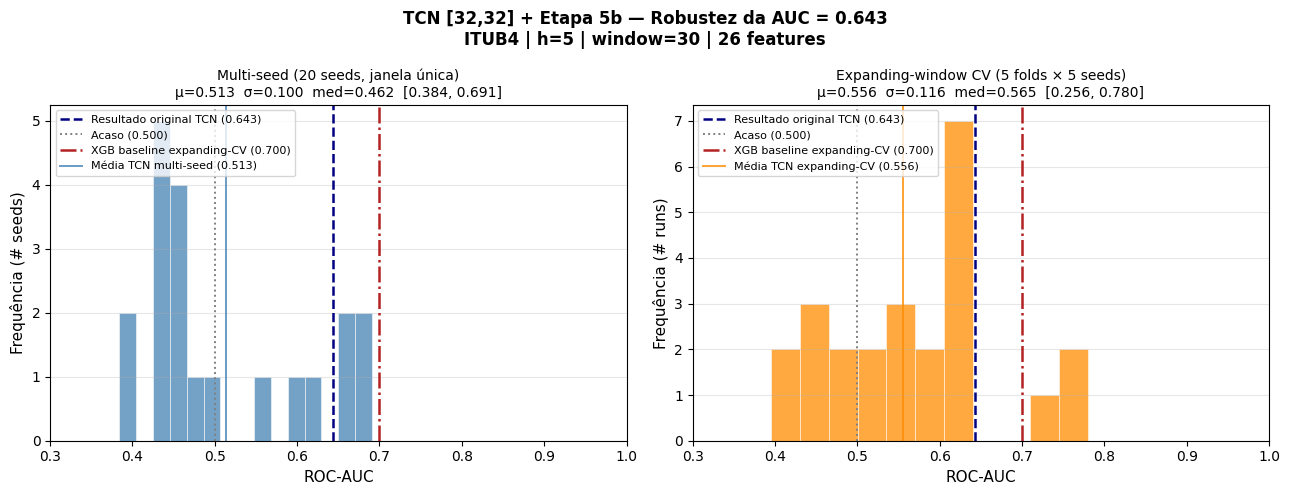

Figura salva em: tcn_validation_hist.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'TCN [32,32] + Etapa 5b — Robustez da AUC = 0.643\n'
    'ITUB4 | h=5 | window=30 | 26 features',
    fontsize=12, fontweight='bold'
)

# ── Painel esquerdo: multi-seed ────────────────────────────────────────────────
ax = axes[0]
ax.hist(aucs_ms, bins=15, color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(0.643, ls='--', color='navy',   lw=1.8, label='Resultado original TCN (0.643)')
ax.axvline(0.500, ls=':',  color='gray',   lw=1.4, label='Acaso (0.500)')
ax.axvline(XGB_BASELINE_AUC, ls='-.', color='firebrick', lw=1.8,
           label=f'XGB baseline expanding-CV ({XGB_BASELINE_AUC:.3f})')
ax.axvline(aucs_ms.mean(), ls='-', color='steelblue', lw=1.4, alpha=0.8,
           label=f'Média TCN multi-seed ({aucs_ms.mean():.3f})')

ax.set_xlabel('ROC-AUC', fontsize=11)
ax.set_ylabel('Frequência (# seeds)', fontsize=11)
ax.set_title(
    f'Multi-seed ({N_SEEDS} seeds, janela única)\n'
    f'μ={aucs_ms.mean():.3f}  σ={aucs_ms.std():.3f}  '
    f'med={np.median(aucs_ms):.3f}  '
    f'[{aucs_ms.min():.3f}, {aucs_ms.max():.3f}]',
    fontsize=10
)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(0.3, 1.0)

# ── Painel direito: expanding-window CV ───────────────────────────────────────
ax = axes[1]
ax.hist(aucs_cv, bins=15, color='darkorange', alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(0.643, ls='--', color='navy',   lw=1.8, label='Resultado original TCN (0.643)')
ax.axvline(0.500, ls=':',  color='gray',   lw=1.4, label='Acaso (0.500)')
ax.axvline(XGB_BASELINE_AUC, ls='-.', color='firebrick', lw=1.8,
           label=f'XGB baseline expanding-CV ({XGB_BASELINE_AUC:.3f})')
ax.axvline(aucs_cv.mean(), ls='-', color='darkorange', lw=1.4, alpha=0.8,
           label=f'Média TCN expanding-CV ({aucs_cv.mean():.3f})')

ax.set_xlabel('ROC-AUC', fontsize=11)
ax.set_ylabel('Frequência (# runs)', fontsize=11)
n_folds_valid = results_cv['fold'].nunique()
ax.set_title(
    f'Expanding-window CV ({n_folds_valid} folds × {N_SEEDS_CV} seeds)\n'
    f'μ={aucs_cv.mean():.3f}  σ={aucs_cv.std():.3f}  '
    f'med={np.median(aucs_cv):.3f}  '
    f'[{aucs_cv.min():.3f}, {aucs_cv.max():.3f}]',
    fontsize=10
)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(0.3, 1.0)

plt.tight_layout()
fig_path = 'tcn_validation_hist.png'
plt.savefig(fig_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'Figura salva em: {fig_path}')

## 7. Análise comparativa: TCN vs Transformer vs XGB baseline

In [14]:
# Tabela de comparação consolidada
comparativo = pd.DataFrame([
    {
        'Modelo':           'Transformer + FinBERT (Etapa 4)',
        'Avaliação':        'Janela única, seed=42',
        'AUC reportado':    0.709,
        'AUC médio (ms)':  0.686,
        'AUC std (ms)':    0.261,
        'AUC médio (CV)':  'N/A',
        'Fonte':           'Capítulo 5 / multi_seed.ipynb',
    },
    {
        'Modelo':           'XGB baseline (5 features preço)',
        'Avaliação':        'Expanding-window CV (5 folds × 5 seeds)',
        'AUC reportado':    XGB_BASELINE_AUC,
        'AUC médio (ms)':  0.641,
        'AUC std (ms)':    0.012,
        'AUC médio (CV)':  XGB_BASELINE_AUC,
        'Fonte':           'expanding_window_cv.ipynb',
    },
    {
        'Modelo':           'TCN [32,32] + Etapa 5b (26 features)',
        'Avaliação':        'Janela única, seed=42',
        'AUC reportado':    0.643,
        'AUC médio (ms)':  round(float(aucs_ms.mean()), 3),
        'AUC std (ms)':    round(float(aucs_ms.std()),  3),
        'AUC médio (CV)':  round(float(aucs_cv.mean()), 3),
        'Fonte':           'tcn_validation.ipynb (este notebook)',
    },
])

print('=== Comparativo consolidado ===')
print(comparativo.to_string(index=False))

=== Comparativo consolidado ===
                              Modelo                               Avaliação  AUC reportado  AUC médio (ms)  AUC std (ms) AUC médio (CV)                                Fonte
     Transformer + FinBERT (Etapa 4)                   Janela única, seed=42          0.709           0.686         0.261            N/A        Capítulo 5 / multi_seed.ipynb
     XGB baseline (5 features preço) Expanding-window CV (5 folds × 5 seeds)          0.700           0.641         0.012            0.7            expanding_window_cv.ipynb
TCN [32,32] + Etapa 5b (26 features)                   Janela única, seed=42          0.643           0.513         0.100          0.556 tcn_validation.ipynb (este notebook)


## 8. Diagnóstico: AUC vs shift de prior por fold (expanding-window)

=== Correlação shift_prior × AUC (expanding-window) ===
  Pearson  r = +0.904  p = 0.035
  Spearman r = +1.000  p = 0.000

  Interpretação:
  → Correlação forte: AUC do TCN é dominada por matching de prior,
    não por capacidade preditiva real. Mesmo colapso do Transformer.


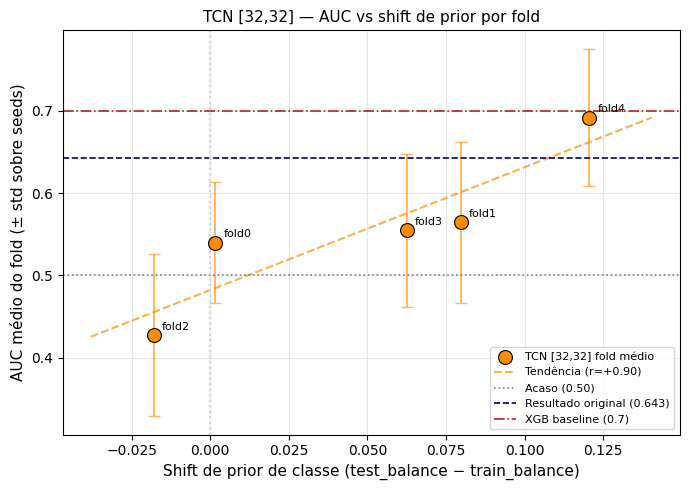

In [15]:
if len(fold_agg) >= 3:
    from scipy.stats import pearsonr, spearmanr
    r_pear, p_pear = pearsonr(fold_agg['shift'], fold_agg['auc_mean'])
    r_spear, p_spear = spearmanr(fold_agg['shift'], fold_agg['auc_mean'])

    print('=== Correlação shift_prior × AUC (expanding-window) ===')
    print(f'  Pearson  r = {r_pear:+.3f}  p = {p_pear:.3f}')
    print(f'  Spearman r = {r_spear:+.3f}  p = {p_spear:.3f}')
    print()
    print('  Interpretação:')
    if abs(r_pear) > 0.6 and p_pear < 0.10:
        print('  → Correlação forte: AUC do TCN é dominada por matching de prior,')
        print('    não por capacidade preditiva real. Mesmo colapso do Transformer.')
    elif abs(r_pear) < 0.3:
        print('  → Correlação fraca: TCN é menos suscetível ao shift de prior')
        print('    do que o Transformer. Avaliação mais robusta.')
    else:
        print('  → Correlação moderada. Investigação adicional necessária.')

    # Scatter: shift × AUC por fold
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        fold_agg['shift'], fold_agg['auc_mean'],
        s=100, c='darkorange', edgecolors='k', linewidths=0.8, zorder=3,
        label='TCN [32,32] fold médio'
    )
    ax.errorbar(
        fold_agg['shift'], fold_agg['auc_mean'],
        yerr=fold_agg['auc_std'].fillna(0),
        fmt='none', color='darkorange', capsize=4, alpha=0.6
    )
    # Linha de tendência
    z = np.polyfit(fold_agg['shift'], fold_agg['auc_mean'], 1)
    xs = np.linspace(fold_agg['shift'].min() - 0.02, fold_agg['shift'].max() + 0.02, 50)
    ax.plot(xs, np.polyval(z, xs), '--', color='darkorange', alpha=0.7,
            label=f'Tendência (r={r_pear:+.2f})')

    for _, row in fold_agg.iterrows():
        ax.annotate(f'fold{int(row["fold"])}', (row['shift'], row['auc_mean']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

    ax.axhline(0.500, ls=':', color='gray',   lw=1.2, label='Acaso (0.50)')
    ax.axhline(0.643, ls='--', color='navy',  lw=1.2, label='Resultado original (0.643)')
    ax.axhline(XGB_BASELINE_AUC, ls='-.', color='firebrick', lw=1.2,
               label=f'XGB baseline ({XGB_BASELINE_AUC})')
    ax.axvline(0.0, ls=':', color='lightgray')

    ax.set_xlabel('Shift de prior de classe (test_balance − train_balance)', fontsize=11)
    ax.set_ylabel('AUC médio do fold (± std sobre seeds)', fontsize=11)
    ax.set_title('TCN [32,32] — AUC vs shift de prior por fold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('tcn_validation_shift.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('Folds insuficientes para análise de correlação (mínimo 3).')

## 9. Conclusão e implicações para a tese

### Critérios de decisão

| Padrão observado | Conclusão | Implicação para o texto |
|---|---|---|
| AUC médio multi-seed ≈ 0.64 ± σ < 0.05, AUC médio CV ≈ 0.64 | **TCN robusto**: resultado original é reproduzível | Reportar TCN como resultado prático sólido; contrastar com fragilidade do Transformer |
| AUC médio multi-seed ≈ 0.64, mas AUC médio CV ≪ 0.64 | **Colapso sob CV**: janela única é enganosa para o TCN também | Estender a crítica metodológica do Cap. 5 ao TCN |
| AUC std multi-seed > 0.10, seeds ruins < 0.50 | **Fragilidade de seed**: mesmo colapso do Transformer | O AUC = 0.643 é ruidoso; reportar com distribuição |
| AUC médio CV < XGB baseline (0.700) | **TCN não supera baseline simples** | Sentimento engenheirado não adiciona valor além de preço sob validação correta |

### Números a inserir no Capítulo 5

In [16]:
print('=== Números para o Capítulo 5 (copiar para o texto) ===')
print()
print('TCN [32,32] + Etapa 5b | ITUB4 | h=5 | window=30')
print(f'  Resultado original (seed=42, janela única):  AUC = 0.643')
print()
print('  Multi-seed (20 seeds, mesma janela):')
print(f'    AUC médio   = {aucs_ms.mean():.3f}')
print(f'    AUC std     = {aucs_ms.std():.3f}')
print(f'    AUC mediana = {np.median(aucs_ms):.3f}')
print(f'    AUC range   = [{aucs_ms.min():.3f}, {aucs_ms.max():.3f}]')
print(f'    Seeds ≥ 0.60 = {(aucs_ms >= 0.60).sum()}/{len(aucs_ms)}')
print()
print('  Expanding-window CV (folds × seeds):')
print(f'    AUC médio   = {aucs_cv.mean():.3f}')
print(f'    AUC std     = {aucs_cv.std():.3f}')
print(f'    AUC mediana = {np.median(aucs_cv):.3f}')
print(f'    AUC range   = [{aucs_cv.min():.3f}, {aucs_cv.max():.3f}]')
print(f'    Δ vs XGB baseline ({XGB_BASELINE_AUC}) = {aucs_cv.mean() - XGB_BASELINE_AUC:+.3f}')
print()
print('Referência XGB baseline expanding-CV: AUC = 0.700')

=== Números para o Capítulo 5 (copiar para o texto) ===

TCN [32,32] + Etapa 5b | ITUB4 | h=5 | window=30
  Resultado original (seed=42, janela única):  AUC = 0.643

  Multi-seed (20 seeds, mesma janela):
    AUC médio   = 0.513
    AUC std     = 0.100
    AUC mediana = 0.462
    AUC range   = [0.384, 0.691]
    Seeds ≥ 0.60 = 6/20

  Expanding-window CV (folds × seeds):
    AUC médio   = 0.556
    AUC std     = 0.116
    AUC mediana = 0.565
    AUC range   = [0.256, 0.780]
    Δ vs XGB baseline (0.7) = -0.144

Referência XGB baseline expanding-CV: AUC = 0.700
